# FreeSurfer cortical thickness colocalizations in subjects with fragile X syndrome

This notebook will demonstrate how to perform a group comparison based on FreeSurfer output.
For that, we will start with actual FreeSurfer output folders, to make translation to your own data as easy as possible.

We will use a small but quite interesting clinical sample from OpenNeuro: ["Rates of cerebral protein synthesis (rCPS) in subjects with fragile X syndrome"](https://openneuro.org/datasets/ds004654/versions/1.0.1).  
Citations: https://doi.org/10.1177/0271678X221090997 and https://doi.org/10.1016/j.nbd.2020.104978.  

The dataset is rather small, however, at the same time, fragile X syndrome (FrX) as a genetic disorder can be expected to have comparably strong effects on cortical thickness, likely in some brain regions more than in others. These characteristics make it interesting for demonstration of colocalization analysis.

We will first download the data from OpenNeuro to a local folder. If you only want to check out how to work with cortical FreeSurfer output, and already have tabulated data for either the coarser Desikan-Killiany ("aparc", 34 parcels per hemisphere) or the finer Destrieux parcellation ("aparc.a2009s", 74 parcels per hemisphere), you might want to jump directly to the analysis [here](#colocalization).


In [1]:
# general imports
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# monkey patch to make progress bars show as ASCII instead of as widgets
import tqdm.notebook
tqdm.notebook.tqdm = tqdm.tqdm
tqdm = tqdm.notebook.tqdm

In [2]:
# load local nispace, for testing
# COMMENT THIS OUT IF YOU RUN THIS
import sys
sys.path.append("/Users/llotter/projects/nispace/")

## Data preparation: Download a FreeSurfer sample from OpenNeuro

Although, we will use only a small part of these data, we will download the complete `freesurfer/sub-{}/stats` folders for each subject as we would have after we processed a dataset with FreeSurfer. It's only table files, so a few MB overall.

[This](./urls_ds004654-1.0.1.json) is a dictionary of the URLs of the files we want to download. Format: `{"url": local_path}`

In [36]:
from nispace.io import read_json

# get the directory of this notebook
notebook_dir = Path().absolute()

# read the URLs from the JSON file
urls = read_json(notebook_dir / "urls_ds004654-1.0.1.json")
#urls

Download all the files. If run like this, the code will download the data into: 
`directory_of_this_notebook/ds004654-1.0.1/`

In [31]:
from nispace.utils.utils_datasets import download

# this will be our dataset directory
dataset_dir = notebook_dir / "ds004654-1.0.1"

# iterate over the URLs and download the files
for url, fp in tqdm(urls.items(), desc="Downloading files..."):
    fp = notebook_dir / fp
    # download the file only if it does not exist already
    if not fp.exists():
        fp.parent.mkdir(parents=True, exist_ok=True)
        download(url, fp)

Notebook path: /Users/llotter/projects/nispace/docs/nb_examples


### Fetch sample data

#### Subject characteristics

This is a BIDS dataset, so there is a `participants.tsv` file that contains subject characteristics.

In [5]:
df_participants = pd.read_table(dataset_dir / "participants.tsv", index_col=0)

# This is what the dataframe looks like:
print("participants.tsv:")
display(df_participants.head(5))

# That's our two groups:
print("Group statistics:")
df_participants.groupby("diagnosis").describe()

participants.tsv:


,diagnosis,age,sex
participant_id,,,
sub-HM02,HC,20,M
sub-HM03,HC,22,M
sub-HM05,HC,23,M
sub-HM06,FrX,23,M
sub-HM07,HC,20,M


Group statistics:


age                                               
          count   mean       std   min   25%   50%   75%   max
diagnosis                                                     
FrX        12.0  20.75  2.179449  18.0  19.0  20.5  23.0  24.0
HC         16.0  21.75  1.612452  19.0  20.0  22.0  23.0  24.0

#### Collect FreeSurfer data

For now, we will use standard FreeSurfer output from the cortical segmentation. The two standard parcellations are Desikan-Killiany and Destrieux.
We assume that you have FreeSurfer installed on your system and accessible from the command line, so we can use the dedicated FreeSurfer command `aparcstats2table` to gather segmentation output across multiple subjects.

One has to run the command separately for each hemisphere and parcellation: Desikan-Killiany: "aparc" and Destrieux: "aparc.a2009s".

In [6]:
import os
import subprocess

# set FreeSurfer's SUBJECTS_DIR to our datasets FreeSurfer output directory
os.environ["SUBJECTS_DIR"] = str(dataset_dir / "derivatives" / "freesurfer")

# we have to run the command separately for each hemisphere and parcellation
for hemi in ["lh", "rh"]:
    for parc in ["aparc", "aparc.a2009s"]:
        
        # this will be our output table file
        aparcstats_file = dataset_dir / f"stats_{parc}_{hemi}.tsv"

        # assemble the command (replace "thickness" with "volume" or "area" to get the other measures)
        cmd = [
            "aparcstats2table",
            "--subjects", " ".join(df_participants.index),
            "--hemi", hemi,
            "--parc", parc,
            "--meas", "thickness",
            "--tablefile", str(aparcstats_file)
        ]
        cmd = " ".join(cmd)
        print(cmd)
        # run the command
        subprocess.run(cmd, shell=True)

aparcstats2table --subjects sub-HM02 sub-HM03 sub-HM05 sub-HM06 sub-HM07 sub-HM08 sub-HM09 sub-HM10 sub-HM15 sub-HM16 sub-HM17 sub-HM18 sub-HM19 sub-HM21 sub-HM22 sub-HM24 sub-HM25 sub-HM28 sub-HM29 sub-HM30 sub-HM31 sub-HM32 sub-HM35 sub-HM36 sub-HM37 sub-HM38 sub-HM39 sub-HM40 --hemi lh --parc aparc --meas thickness --tablefile /Users/llotter/projects/nispace/docs/nb_examples/ds004654-1.0.1/stats_aparc_lh.tsv
SUBJECTS_DIR : /Users/llotter/projects/nispace/docs/nb_examples/ds004654-1.0.1/derivatives/freesurfer
Parsing the .stats files
Building the table..
Writing the table to /Users/llotter/projects/nispace/docs/nb_examples/ds004654-1.0.1/stats_aparc_lh.tsv
aparcstats2table --subjects sub-HM02 sub-HM03 sub-HM05 sub-HM06 sub-HM07 sub-HM08 sub-HM09 sub-HM10 sub-HM15 sub-HM16 sub-HM17 sub-HM18 sub-HM19 sub-HM21 sub-HM22 sub-HM24 sub-HM25 sub-HM28 sub-HM29 sub-HM30 sub-HM31 sub-HM32 sub-HM35 sub-HM36 sub-HM37 sub-HM38 sub-HM39 sub-HM40 --hemi lh --parc aparc.a2009s --meas thickness --tabl

#### Get Euler number as a quality covariate

The Euler number is quite a good quality measure for structural MRI scans. FreeSurfer outputs is only via the `asegstats2table` command.

In [7]:
# this will be our output table file
asegstats_file = dataset_dir / f"stats_aseg.tsv"

# assemble the command 
cmd = [
    "asegstats2table",
    "--subjects", " ".join(df_participants.index),
    "--tablefile", str(asegstats_file)
]
cmd = " ".join(cmd)
print(cmd)

# run the command
subprocess.run(cmd, shell=True)

asegstats2table --subjects sub-HM02 sub-HM03 sub-HM05 sub-HM06 sub-HM07 sub-HM08 sub-HM09 sub-HM10 sub-HM15 sub-HM16 sub-HM17 sub-HM18 sub-HM19 sub-HM21 sub-HM22 sub-HM24 sub-HM25 sub-HM28 sub-HM29 sub-HM30 sub-HM31 sub-HM32 sub-HM35 sub-HM36 sub-HM37 sub-HM38 sub-HM39 sub-HM40 --tablefile /Users/llotter/projects/nispace/docs/nb_examples/ds004654-1.0.1/stats_aseg.tsv
SUBJECTS_DIR : /Users/llotter/projects/nispace/docs/nb_examples/ds004654-1.0.1/derivatives/freesurfer
Parsing the .stats files
Building the table..
Writing the table to /Users/llotter/projects/nispace/docs/nb_examples/ds004654-1.0.1/stats_aseg.tsv


CompletedProcess(args='asegstats2table --subjects sub-HM02 sub-HM03 sub-HM05 sub-HM06 sub-HM07 sub-HM08 sub-HM09 sub-HM10 sub-HM15 sub-HM16 sub-HM17 sub-HM18 sub-HM19 sub-HM21 sub-HM22 sub-HM24 sub-HM25 sub-HM28 sub-HM29 sub-HM30 sub-HM31 sub-HM32 sub-HM35 sub-HM36 sub-HM37 sub-HM38 sub-HM39 sub-HM40 --tablefile /Users/llotter/projects/nispace/docs/nb_examples/ds004654-1.0.1/stats_aseg.tsv', returncode=0)

### Load FreeSurfer stats tables

Now we load the FreeSurfer stats tables into pandas dataframes. We will combine left and right hemisphere data into one dataframe (L -> R). This is the way NiSpace works with bilateral surface data.

#### Desikan-Killiany parcellation

We'll start with the Desikan-Killiany parcellation. Load left and right dataframes, drop unnecessary columns, and concatenate them.

In [8]:
# load left and right hemisphere data
df_desikan_lh = pd.read_table(dataset_dir / "stats_aparc_lh.tsv", index_col=0)
df_desikan_rh = pd.read_table(dataset_dir / "stats_aparc_rh.tsv", index_col=0)

# display the first 5 rows of left hemisphere
print("Desikan-Killiany left hemisphere: shape:", df_desikan_lh.shape)
display(df_desikan_lh.head(5))

# There's 3 columns we dont need for our core analysis: {lh|rh}_MeanThickness_thickness, BrainSegVolNotVent, eTIV
df_desikan_lh = df_desikan_lh.drop(columns=["lh_MeanThickness_thickness", "BrainSegVolNotVent", "eTIV"])
df_desikan_rh = df_desikan_rh.drop(columns=["rh_MeanThickness_thickness", "BrainSegVolNotVent", "eTIV"])
print("shape after dropping columns:", df_desikan_lh.shape)

# concatenate left and right hemisphere
df_desikan = pd.concat([df_desikan_lh, df_desikan_rh], axis=1)
print("Shape after concatenation:", df_desikan.shape)

Desikan-Killiany left hemisphere: shape: (28, 37)


,lh_bankssts_thickness,lh_caudalanteriorcingulate_thickness,lh_caudalmiddlefrontal_thickness,lh_cuneus_thickness,lh_entorhinal_thickness,lh_fusiform_thickness,lh_inferiorparietal_thickness,lh_inferiortemporal_thickness,lh_isthmuscingulate_thickness,lh_lateraloccipital_thickness,...,lh_superiorparietal_thickness,lh_superiortemporal_thickness,lh_supramarginal_thickness,lh_frontalpole_thickness,lh_temporalpole_thickness,lh_transversetemporal_thickness,lh_insula_thickness,lh_MeanThickness_thickness,BrainSegVolNotVent,eTIV
lh.aparc.thickness,,,,,,,,,,,,,,,,,,,,,
sub-HM02,2.842,2.451,2.708,2.058,3.014,2.963,2.416,3.078,2.492,2.088,...,2.247,3.139,2.680,3.043,3.743,2.909,3.176,2.66845,1498381.0,1.852958e+06
sub-HM03,2.639,2.769,2.789,2.091,3.786,2.999,2.719,3.105,2.408,2.227,...,2.357,3.148,2.766,2.527,4.229,2.946,3.040,2.74607,1304548.0,1.609761e+06
sub-HM05,2.440,2.532,2.647,1.938,2.957,2.735,2.598,2.660,2.326,2.087,...,2.149,3.138,2.573,2.994,3.825,2.741,3.121,2.55060,1422817.0,1.525428e+06
sub-HM06,2.538,2.442,2.730,2.098,4.131,3.027,2.544,2.958,2.263,2.248,...,2.373,3.326,2.663,2.987,4.294,2.768,3.416,2.67984,1473457.0,1.950892e+06
sub-HM07,2.576,2.478,2.545,1.953,2.741,2.590,2.463,2.581,2.590,2.166,...,2.107,2.949,2.610,2.449,3.909,2.198,2.579,2.49447,1481353.0,1.856110e+06


shape after dropping columns: (28, 34)
Shape after concatenation: (28, 68)


#### Destrieux parcellation

We'll do the same thing for the Destrieux parcellation.

In [9]:
# load left and right hemisphere data
df_destrieux_lh = pd.read_table(dataset_dir / "stats_aparc.a2009s_lh.tsv", index_col=0)
df_destrieux_rh = pd.read_table(dataset_dir / "stats_aparc.a2009s_rh.tsv", index_col=0)

# display the first 5 rows of left hemisphere
print("Destrieux left hemisphere: shape:", df_destrieux_lh.shape)
display(df_destrieux_lh.head(5))

# drop the unnecessary columns
df_destrieux_lh = df_destrieux_lh.drop(columns=["lh_MeanThickness_thickness", "BrainSegVolNotVent", "eTIV"])
df_destrieux_rh = df_destrieux_rh.drop(columns=["rh_MeanThickness_thickness", "BrainSegVolNotVent", "eTIV"])
print("shape after dropping columns:", df_destrieux_lh.shape)

# concatenate left and right hemisphere
df_destrieux = pd.concat([df_destrieux_lh, df_destrieux_rh], axis=1)
print("Shape after concatenation:", df_destrieux.shape)

Destrieux left hemisphere: shape: (28, 77)


,lh_G_and_S_frontomargin_thickness,lh_G_and_S_occipital_inf_thickness,lh_G_and_S_paracentral_thickness,lh_G_and_S_subcentral_thickness,lh_G_and_S_transv_frontopol_thickness,lh_G_and_S_cingul-Ant_thickness,lh_G_and_S_cingul-Mid-Ant_thickness,lh_G_and_S_cingul-Mid-Post_thickness,lh_G_cingul-Post-dorsal_thickness,lh_G_cingul-Post-ventral_thickness,...,lh_S_precentral-inf-part_thickness,lh_S_precentral-sup-part_thickness,lh_S_suborbital_thickness,lh_S_subparietal_thickness,lh_S_temporal_inf_thickness,lh_S_temporal_sup_thickness,lh_S_temporal_transverse_thickness,lh_MeanThickness_thickness,BrainSegVolNotVent,eTIV
lh.aparc.a2009s.thickness,,,,,,,,,,,,,,,,,,,,,
sub-HM02,2.669,2.045,2.278,2.818,2.824,2.771,2.922,2.680,3.208,3.248,...,2.544,2.530,2.194,2.284,2.820,2.673,2.828,2.66845,1498381.0,1.852958e+06
sub-HM03,2.564,2.214,2.569,3.028,2.472,3.122,3.057,2.928,3.142,3.013,...,2.795,2.887,2.478,2.437,2.658,2.737,2.699,2.74607,1304548.0,1.609761e+06
sub-HM05,2.247,2.427,2.347,2.733,2.791,2.751,2.916,2.743,2.778,2.696,...,2.828,2.641,2.301,2.459,2.496,2.666,2.621,2.55060,1422817.0,1.525428e+06
sub-HM06,2.508,2.372,2.502,3.089,2.841,2.806,2.725,2.787,3.341,2.398,...,2.778,2.465,2.627,2.415,2.574,2.723,2.623,2.67984,1473457.0,1.950892e+06
sub-HM07,2.323,2.329,2.557,2.778,2.428,2.649,2.808,2.602,3.128,2.865,...,2.539,2.597,2.401,2.417,2.289,2.570,2.454,2.49447,1481353.0,1.856110e+06


shape after dropping columns: (28, 74)
Shape after concatenation: (28, 148)


#### Euler number and eTIV as covariates

Euler number is stored as "SurfaceHoles". We will furthermore extract total intracranial volume (eTIV) data.

In [10]:
df_aseg = pd.read_table(dataset_dir / "stats_aseg.tsv", index_col=0)
df_aseg.head()

# We'll save them in our participants table
df_participants["euler_number"] = df_aseg["SurfaceHoles"].values
df_participants["eTIV"] = df_aseg["EstimatedTotalIntraCranialVol"].values

# lets see some descriptive statistics
df_participants.describe()

,age,euler_number,eTIV
count,28.000000,28.000000,2.800000e+01
mean,21.321429,40.000000,1.887269e+06
std,1.906200,12.719189,1.965039e+05
min,18.000000,16.000000,1.525428e+06
25%,20.000000,31.000000,1.738014e+06
50%,21.500000,39.500000,1.943034e+06
75%,23.000000,48.250000,2.012314e+06
max,24.000000,67.000000,2.260434e+06


## Colocalization <a id="colocalization"></a>

Now to the main analysis. If you skipped to here, make sure that your data looks like this: (n_subjects x n_parcels)

In [11]:
print("For Desikan-Killiany parcellation:")
display(df_desikan.head(3))

print("For Destrieux parcellation:")
display(df_destrieux.head(3))

For Desikan-Killiany parcellation:


,lh_bankssts_thickness,lh_caudalanteriorcingulate_thickness,lh_caudalmiddlefrontal_thickness,lh_cuneus_thickness,lh_entorhinal_thickness,lh_fusiform_thickness,lh_inferiorparietal_thickness,lh_inferiortemporal_thickness,lh_isthmuscingulate_thickness,lh_lateraloccipital_thickness,...,rh_rostralanteriorcingulate_thickness,rh_rostralmiddlefrontal_thickness,rh_superiorfrontal_thickness,rh_superiorparietal_thickness,rh_superiortemporal_thickness,rh_supramarginal_thickness,rh_frontalpole_thickness,rh_temporalpole_thickness,rh_transversetemporal_thickness,rh_insula_thickness
sub-HM02,2.842,2.451,2.708,2.058,3.014,2.963,2.416,3.078,2.492,2.088,...,3.038,2.562,3.000,2.096,3.084,2.653,2.807,4.090,2.983,3.052
sub-HM03,2.639,2.769,2.789,2.091,3.786,2.999,2.719,3.105,2.408,2.227,...,3.205,2.677,3.216,2.431,3.193,2.737,3.261,4.042,2.902,3.262
sub-HM05,2.440,2.532,2.647,1.938,2.957,2.735,2.598,2.660,2.326,2.087,...,2.874,2.316,2.859,2.200,2.868,2.733,2.805,3.774,2.292,3.150


For Destrieux parcellation:


,lh_G_and_S_frontomargin_thickness,lh_G_and_S_occipital_inf_thickness,lh_G_and_S_paracentral_thickness,lh_G_and_S_subcentral_thickness,lh_G_and_S_transv_frontopol_thickness,lh_G_and_S_cingul-Ant_thickness,lh_G_and_S_cingul-Mid-Ant_thickness,lh_G_and_S_cingul-Mid-Post_thickness,lh_G_cingul-Post-dorsal_thickness,lh_G_cingul-Post-ventral_thickness,...,rh_S_parieto_occipital_thickness,rh_S_pericallosal_thickness,rh_S_postcentral_thickness,rh_S_precentral-inf-part_thickness,rh_S_precentral-sup-part_thickness,rh_S_suborbital_thickness,rh_S_subparietal_thickness,rh_S_temporal_inf_thickness,rh_S_temporal_sup_thickness,rh_S_temporal_transverse_thickness
sub-HM02,2.669,2.045,2.278,2.818,2.824,2.771,2.922,2.680,3.208,3.248,...,2.337,1.559,2.201,2.677,2.833,2.248,2.697,2.667,2.820,2.889
sub-HM03,2.564,2.214,2.569,3.028,2.472,3.122,3.057,2.928,3.142,3.013,...,2.374,1.895,2.266,2.716,2.737,3.233,2.740,2.461,2.758,3.265
sub-HM05,2.247,2.427,2.347,2.733,2.791,2.751,2.916,2.743,2.778,2.696,...,2.310,1.658,2.190,2.512,2.456,2.769,2.499,2.381,2.483,2.018


### Fetch reference data

First, we will fetch our "reference data" for both parcellations.  
In NiSpace, as "reference data" we refer to the data that you would like to compare your sample data to. Coming from the JuSpace toolbox, this might often be a set of PET maps for different tracers.

We will go with that and load the standard set of PET maps, one per tracer for a set of unique targets.
NiSpace ships both the imaging maps themselves but also pre-computed parcellated data. The latter can be fetched by passing a parcellation to the `fetch_reference` function.

In [12]:
from nispace.datasets import fetch_reference

# Desikan-Killiany
df_reference_desikan = fetch_reference(
    "pet", 
    collection="UniqueTracers", # that's the default collection of PET maps
    parcellation="DesikanKilliany", # our parcellation
)

# Destrieux
df_reference_destrieux = fetch_reference(
    "pet", 
    collection="UniqueTracers", 
    parcellation="Destrieux",
    print_references=False, # we supress printing the long list of references here
)

print("Shape of Desikan-Killiany reference data:", df_reference_desikan.shape)
print("Shape of Destrieux reference data:", df_reference_destrieux.shape)

INFO | 24/01/25 17:39:14 | nispace: Loading pet maps.
INFO | 24/01/25 17:39:14 | nispace: Applying collection filter from: /Users/llotter/nispace-data/reference/pet/collection-UniqueTracers.collect.
INFO | 24/01/25 17:39:14 | nispace: Loading parcellated data: DesikanKilliany
INFO | 24/01/25 17:39:14 | nispace: Standardizing parcellated data.
The NiSpace "PET" dataset is based on openly available nuclear imaging maps largely accessed via neuromaps 
(https://neuromaps-main.readthedocs.io/). If requested in the varying original spaces and resolutions (termed "MNI152"),
the maps are downloaded directly from the source and cached locally. If, as is highly recommended, the maps are requested in 
a defined space ("MNI152NLin2009cAsym" or "MNI152NLin6Asym"), they are downloaded from the NiSpace OSF project (find them in 
`~HOME/nispace-data/reference/pet/map`). The NiSpace-hosted maps were directly registered to 2mm MNI152NLin6Asym space, 
and then transformed to 2mm MNI152NLin2009cAsym with 

When working with parcellated data, it always makes sense to check if the parcel order aligns between different datasets. We'll print the columns of the sample and reference data to check if they align.

Here, you can see that the columns of the sample data and reference data align, albeit having different naming schemes.


In [13]:
print("Columns of Desikan-Killiany sample and reference data:")
display(pd.DataFrame({"Sample": df_desikan.columns, "Reference": df_reference_desikan.columns}))

print("Columns of Destrieux sample and reference data:")
display(pd.DataFrame({"Sample": df_destrieux.columns, "Reference": df_reference_destrieux.columns}))


Columns of Desikan-Killiany sample and reference data:


,Sample,Reference
0,lh_bankssts_thickness,1_LH_CX_bankssts
1,lh_caudalanteriorcingulate_thickness,2_LH_CX_caudalanteriorcingulate
2,lh_caudalmiddlefrontal_thickness,3_LH_CX_caudalmiddlefrontal
3,lh_cuneus_thickness,4_LH_CX_cuneus
4,lh_entorhinal_thickness,5_LH_CX_entorhinal
...,...,...
63,rh_supramarginal_thickness,64_RH_CX_supramarginal
64,rh_frontalpole_thickness,65_RH_CX_frontalpole
65,rh_temporalpole_thickness,66_RH_CX_temporalpole
66,rh_transversetemporal_thickness,67_RH_CX_transversetemporal


Columns of Destrieux sample and reference data:


,Sample,Reference
0,lh_G_and_S_frontomargin_thickness,1_LH_CX_G_and_S_frontomargin
1,lh_G_and_S_occipital_inf_thickness,2_LH_CX_G_and_S_occipital_inf
2,lh_G_and_S_paracentral_thickness,3_LH_CX_G_and_S_paracentral
3,lh_G_and_S_subcentral_thickness,4_LH_CX_G_and_S_subcentral
4,lh_G_and_S_transv_frontopol_thickness,5_LH_CX_G_and_S_transv_frontopol
...,...,...
143,rh_S_suborbital_thickness,144_RH_CX_S_suborbital
144,rh_S_subparietal_thickness,145_RH_CX_S_subparietal
145,rh_S_temporal_inf_thickness,146_RH_CX_S_temporal_inf
146,rh_S_temporal_sup_thickness,147_RH_CX_S_temporal_sup


###  Check for "classical" group differences across parcels

This would be the default FreeSurfer analysis in a very easy fashion. We'll perform a t-test for each parcel to check if there are significant differences between the two groups.

In [14]:
from scipy.stats import ttest_ind

# run t-test for each parcel
res_ttest = ttest_ind(
    df_desikan[df_participants.diagnosis == "FrX"],
    df_desikan[df_participants.diagnosis == "HC"],
    axis=0
)

# put the output into a dataframe
df_ttest = pd.DataFrame(
    {   
        "Tvalue": res_ttest.statistic,
        "pvalue": res_ttest.pvalue,
        "df": res_ttest.df,
        "hemi": ["L" if l.startswith("lh_") else "R" for l in df_desikan.columns]
    }, 
    index=df_desikan.columns
)

# print the results sorted by p value
print("Results sorted by p value:")
df_ttest.sort_values("pvalue").head(5)


Results sorted by p value:


,Tvalue,pvalue,df,hemi
lh_parstriangularis_thickness,4.149075,0.000317,26.0,L
lh_rostralanteriorcingulate_thickness,3.728536,0.000945,26.0,L
lh_entorhinal_thickness,3.701004,0.001015,26.0,L
rh_middletemporal_thickness,3.354410,0.002450,26.0,R
rh_lateraloccipital_thickness,3.209261,0.003521,26.0,R


We have a simple function ready to inspect the results in a 3D viewer for one hemisphere. 

We can observe a tendency towards increased cortical thickness in specific brain areas. Our colocalization analysis will now serve to find a pattern in the reference data that is most correlated with the observed pattern in the sample data. This could give us insights into potential mechanisms that could have led to the observed alteration pattern.

In [15]:
from nispace.plotting import view_surf

# plot
view_surf(df_ttest.loc[df_ttest.hemi == "L", "Tvalue"], parcellation="DesikanKilliany", template="fsaverage", hemi="L")

### Perform colocalization analysis <a id="perform_colocalization_analysis"></a>

Finally! After all this data-wrangling, we can perform our main analysis.

#### Simple group comparison using the Desikan-Killiany parcellation

We'll start with a simple group comparison based on effect size difference maps. This will do the following:
1. it will take the sample data and calculate, for each parcel, the effect size difference between the two groups
2. it will correlate the effect size difference maps with the reference data across parcels, separately for each reference map
3. it will calculate exact p values for each correlation coefficient by permuting the groups and re-running steps 1 and 2

The function performs a whole workflow in one go and outputs a overview plots of the "design matrix" and the results.
Minimum input are the reference and sample data, the name of the parcellation (or surface files), and a 0/1 vector indicating group memberships.

We have data for two parcellations, but we'll start with the "simpler" Desikan-Killiany parcellation. We can expect that the results will be a bit more coarse with likely lower effect sizes for the Desikan-Killiany parcellation compared to the more fine-grained Destrieux parcellation.

participant_id
sub-HM02    1
sub-HM03    1
sub-HM05    1
sub-HM06    0
sub-HM07    1
Name: diagnosis, dtype: int64

INFO | 24/01/25 17:39:14 | nispace: Using integrated parcellation DesikanKilliany.
INFO | 24/01/25 17:39:14 | nispace: *** NiSpace.fit() - Data extraction and preparation. ***
INFO | 24/01/25 17:39:14 | nispace: Loading parcellation 'DesikanKilliany' in 'fsaverage' space.
INFO | 24/01/25 17:39:14 | nispace: Loaded integrated parcellation with pre-calculated distance matrix.
INFO | 24/01/25 17:39:14 | nispace: Checking input data for 'x' (should be, e.g., PET data):
INFO | 24/01/25 17:39:14 | nispace: Input type: DataFrame, assuming parcellated data with shape (n_files/subjects/etc, n_parcels).
WARNING | 24/01/25 17:39:14 | nispace: Parcellated data contains nan values!
INFO | 24/01/25 17:39:14 | nispace: Got 'x' data for 28 x 68 parcels.
INFO | 24/01/25 17:39:14 | nispace: Checking input data for 'y' (should be, e.g., subject data):
INFO | 24/01/25 17:39:14 | nispace: Input type: DataFrame, assuming parcellated data with shape (n_files/subjects/etc, n_parcels).
INFO | 24/01/25 17:39:14

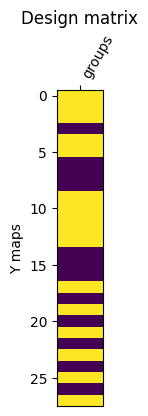

INFO | 24/01/25 17:39:14 | nispace: *** NiSpace.transform_y() - Y transformation and comparison. ***
INFO | 24/01/25 17:39:14 | nispace: Groups/sessions vector provided, ensuring dummy-coding.
INFO | 24/01/25 17:39:14 | nispace: Applying Y transform 'hedges(a,b)'.
INFO | 24/01/25 17:39:14 | nispace: *** NiSpace.colocalize() - Estimating X & Y colocalizations. ***
INFO | 24/01/25 17:39:14 | nispace: Running 'spearman' colocalization with 'hedges(a,b)' transform.


Colocalizing (spearman, -1 proc): 100%|██████████| 1/1 [00:00<00:00, 88.18it/s]


INFO | 24/01/25 17:39:19 | nispace: *** NiSpace.permute() - Estimate exact non-parametric p values. ***
INFO | 24/01/25 17:39:19 | nispace: Permutation of: Y groups.
INFO | 24/01/25 17:39:19 | nispace: Loading transformed Y data, transform = 'hedges(a,b)'.
INFO | 24/01/25 17:39:19 | nispace: Will calculate p values for mean calculation across Y maps. Set 'p_from_average_y_coloc' = False to change this behavior.
INFO | 24/01/25 17:39:19 | nispace: Loading observed colocalizations (method = 'spearman').
INFO | 24/01/25 17:39:19 | nispace: Generating permuted Y groups.
INFO | 24/01/25 17:39:19 | nispace: Permuting groups/sessions vector, strategy: unpaired, proportional.


Null colocalizations (spearman, -1 proc):   0%|          | 0/10000 [00:00<?, ?it/s]/Applications/miniforge3/envs/nsp309/lib/python3.9/site-packages/joblib/externals/loky/process_executor.py:752: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(
Null colocalizations (spearman, -1 proc): 100%|██████████| 10000/10000 [00:02<00:00, 4511.32it/s]


INFO | 24/01/25 17:39:30 | nispace: Calculating exact p-values (tails = {'rho': 'two'}).
INFO | 24/01/25 17:39:30 | nispace: *** NiSpace.correct_p() - Correct p values for multiple comparisons. ***
INFO | 24/01/25 17:39:30 | nispace: *** NiSpace.plot() - Plot colocalization results. ***
INFO | 24/01/25 17:39:31 | nispace: Creating categorical plot for method spearman, colocalization stat rho.


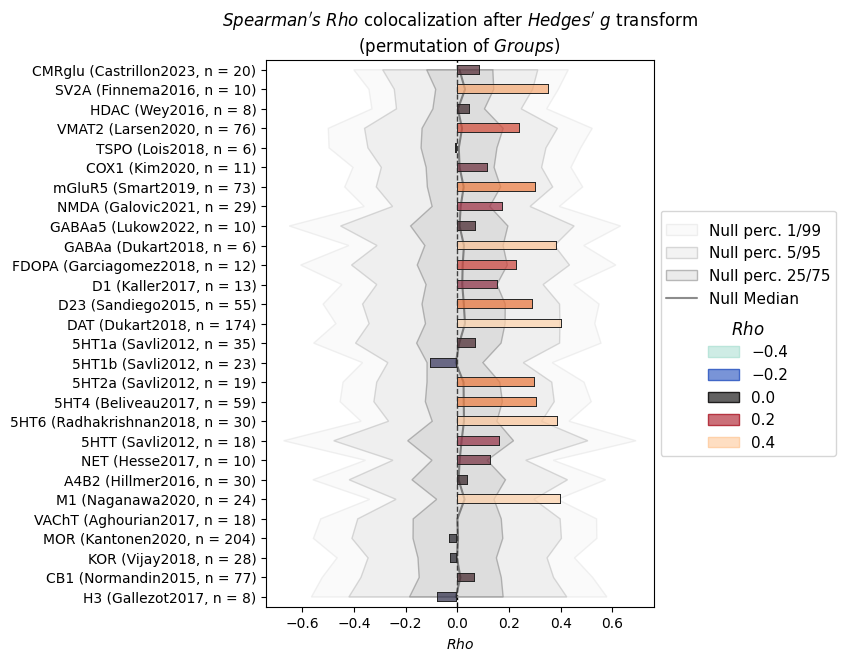

INFO | 24/01/25 17:39:31 | nispace: Returning colocalizations: 
| METHOD   | XSEA  | X_REDUCTION | Y_TRANSFORM | 
| spearman | False | False       | hedges(a,b) | 
INFO | 24/01/25 17:39:31 | nispace: Returning p values: 
| METHOD   | PERMUTE_WHAT | XSEA  | MC_METHOD | NORM  | X_REDUCTION | Y_TRANSFORM | 
| spearman | groups       | False | None      | False | False       | hedges(a,b) | 
INFO | 24/01/25 17:39:31 | nispace: Returning p values: 
| METHOD   | PERMUTE_WHAT | XSEA  | MC_METHOD | NORM  | X_REDUCTION | Y_TRANSFORM | 
| spearman | groups       | False | fdrbh     | False | False       | hedges(a,b) | 


In [16]:
from nispace.workflows import group_comparison

# build the design matrix
groups = df_participants.diagnosis.map({"FrX": 0, "HC": 1})
display(groups.head(5))

# run
colocs, pvalues, qvalues, nsp_object = group_comparison(
    y=df_desikan, # sample data
    x=df_reference_desikan, # reference data
    parcellation="DesikanKilliany", # parcellation
    design=groups, # group membership
    group_comparison="hedges(a,b)", # effect size difference 
    colocalization_method="spearman", # spearman correlation betw. each x and y
    n_perm=10000, # number of permutations for exact p values
    n_proc=-1, # number of cores to use (-1 = all available)
    verbose=True,
)

The plot (null distributions in gray) shows that there are some borderline significant results but the effects are not too strong. As said above, we can expect the results to be stronger with the more fine-grained Destrieux parcellation. 

Here's the top 5 results (FDR-corrected) of the Desikan-Killiany results (not significant at FDR=0.05):

In [17]:
qvalues.T["mean"].sort_values().head(5)

set                          map                                                          
General                      target-SV2A_tracer-ucbj_n-10_dx-hc_pub-finnema2016               0.371467
Serotonin                    target-5HT6_tracer-gsk215083_n-30_dx-hc_pub-radhakrishnan2018    0.371467
Noradrenaline/Acetylcholine  target-M1_tracer-lsn3172176_n-24_dx-hc_pub-naganawa2020          0.371467
Dopamine                     target-DAT_tracer-fpcit_n-174_dx-hc_pub-dukart2018               0.516320
GABA                         target-GABAa_tracer-flumazenil_n-6_dx-hc_pub-dukart2018          0.516320
Name: mean, dtype: float32

The outputs of the workflow function are:
- `colocs`: the correlation coefficients between the effect size maps and the reference data across parcels
- `pvalues`: the p values for each correlation coefficient
- `qvalues`: the FDR-corrected p values for each correlation coefficient
- `nsp_object`: the NiSpace object, which contains the results and can be used for further analyses
We will print the first three dataframes:

In [18]:
display("Colocalization:", colocs)
display("p values:", pvalues)
display("q values:", qvalues)

'Colocalization:'

set                                                   General  \
map    target-CMRglu_tracer-fdg_n-20_dx-hc_pub-castrillon2023   
hedges                                           0.087177       

set                                                        \
map    target-SV2A_tracer-ucbj_n-10_dx-hc_pub-finnema2016   
hedges                                           0.352842   

set                                                          \
map    target-HDAC_tracer-martinostat_n-8_dx-hc_pub-wey2016   
hedges                                           0.049627     

set                                                        \
map    target-VMAT2_tracer-dtbz_n-76_dx-hc_pub-larsen2020   
hedges                                           0.243103   

set                                           Immunity  \
map    target-TSPO_tracer-pbr28_n-6_dx-hc_pub-lois2018   
hedges                                       -0.008665   

set                                                    \
map    target-COX1_tracer-ps13_n-11_dx-hc_pub-kim2020   
hedges                                        0.11982   

set                                               Glutamate  \
map    target-mGluR5_tracer-abp688_n-73_dx-hc_pub-smart2019   
hedges                                           0.303235     

set                                                         \
map    target-NMDA_tracer-ge179_n-29_dx-hc_pub-galovic2021   
hedges                                           0.176093    

set                                                      GABA  \
map    target-GABAa5_tracer-ro154513_n-10_dx-hc_pub-lukow2022   
hedges                                           0.071274       

set                                                             ...  \
map    target-GABAa_tracer-flumazenil_n-6_dx-hc_pub-dukart2018  ...   
hedges                                           0.384012       ...   

set                                                        Serotonin  \
map    target-5HT6_tracer-gsk215083_n-30_dx-hc_pub-radhakrishnan2018   
hedges                                           0.388693              

set                                                      \
map    target-5HTT_tracer-dasb_n-18_dx-hc_pub-savli2012   
hedges                                         0.163992   

set                       Noradrenaline/Acetylcholine  \
map    target-NET_tracer-mrb_n-10_dx-hc_pub-hesse2017   
hedges                                       0.130134   

set                                                             \
map    target-A4B2_tracer-flubatine_n-30_dx-hc_pub-hillmer2016   
hedges                                           0.042358        

set                                                             \
map    target-M1_tracer-lsn3172176_n-24_dx-hc_pub-naganawa2020   
hedges                                           0.399843        

set                                                            \
map    target-VAChT_tracer-feobv_n-18_dx-hc_pub-aghourian2017   
hedges                                          -0.001374       

set                                       Opiods/Endocannabinoids  \
map    target-MOR_tracer-carfentanil_n-204_dx-hc_pub-kantonen2020   
hedges                                          -0.033349           

set                                                          \
map    target-KOR_tracer-ly2795050_n-28_dx-hc_pub-vijay2018   
hedges                                           -0.02963     

set                                                         \
map    target-CB1_tracer-omar_n-77_dx-hc_pub-normandin2015   
hedges                                            0.06809    

set                                                Histamine  
map    target-H3_tracer-gsk189254_n-8_dx-hc_pub-gallezot2017  
hedges                                           -0.07849     

[1 rows x 28 columns]

'p values:'

set                                                 General  \
map  target-CMRglu_tracer-fdg_n-20_dx-hc_pub-castrillon2023   
mean                                             0.6724       

set                                                      \
map  target-SV2A_tracer-ucbj_n-10_dx-hc_pub-finnema2016   
mean                                              0.038   

set                                                        \
map  target-HDAC_tracer-martinostat_n-8_dx-hc_pub-wey2016   
mean                                             0.7586     

set                                                      \
map  target-VMAT2_tracer-dtbz_n-76_dx-hc_pub-larsen2020   
mean                                             0.3314   

set                                         Immunity  \
map  target-TSPO_tracer-pbr28_n-6_dx-hc_pub-lois2018   
mean                                          0.9514   

set                                                  \
map  target-COX1_tracer-ps13_n-11_dx-hc_pub-kim2020   
mean                                         0.5764   

set                                             Glutamate  \
map  target-mGluR5_tracer-abp688_n-73_dx-hc_pub-smart2019   
mean                                              0.185     

set                                                       \
map  target-NMDA_tracer-ge179_n-29_dx-hc_pub-galovic2021   
mean                                             0.3216    

set                                                    GABA  \
map  target-GABAa5_tracer-ro154513_n-10_dx-hc_pub-lukow2022   
mean                                             0.8204       

set                                                           ...  \
map  target-GABAa_tracer-flumazenil_n-6_dx-hc_pub-dukart2018  ...   
mean                                             0.0908       ...   

set                                                      Serotonin  \
map  target-5HT6_tracer-gsk215083_n-30_dx-hc_pub-radhakrishnan2018   
mean                                             0.0398              

set                                                    \
map  target-5HTT_tracer-dasb_n-18_dx-hc_pub-savli2012   
mean                                           0.6162   

set                     Noradrenaline/Acetylcholine  \
map  target-NET_tracer-mrb_n-10_dx-hc_pub-hesse2017   
mean                                         0.4416   

set                                                           \
map  target-A4B2_tracer-flubatine_n-30_dx-hc_pub-hillmer2016   
mean                                             0.8908        

set                                                           \
map  target-M1_tracer-lsn3172176_n-24_dx-hc_pub-naganawa2020   
mean                                             0.0158        

set                                                          \
map  target-VAChT_tracer-feobv_n-18_dx-hc_pub-aghourian2017   
mean                                              0.994       

set                                     Opiods/Endocannabinoids  \
map  target-MOR_tracer-carfentanil_n-204_dx-hc_pub-kantonen2020   
mean                                             0.8888           

set                                                        \
map  target-KOR_tracer-ly2795050_n-28_dx-hc_pub-vijay2018   
mean                                             0.9096     

set                                                       \
map  target-CB1_tracer-omar_n-77_dx-hc_pub-normandin2015   
mean                                              0.797    

set                                              Histamine  
map  target-H3_tracer-gsk189254_n-8_dx-hc_pub-gallezot2017  
mean                                             0.7852     

[1 rows x 28 columns]

'q values:'

set                                                 General  \
map  target-CMRglu_tracer-fdg_n-20_dx-hc_pub-castrillon2023   
mean                                           0.979569       

set                                                      \
map  target-SV2A_tracer-ucbj_n-10_dx-hc_pub-finnema2016   
mean                                           0.371467   

set                                                        \
map  target-HDAC_tracer-martinostat_n-8_dx-hc_pub-wey2016   
mean                                           0.979569     

set                                                      \
map  target-VMAT2_tracer-dtbz_n-76_dx-hc_pub-larsen2020   
mean                                           0.843564   

set                                         Immunity  \
map  target-TSPO_tracer-pbr28_n-6_dx-hc_pub-lois2018   
mean                                        0.986637   

set                                                  \
map  target-COX1_tracer-ps13_n-11_dx-hc_pub-kim2020   
mean                                       0.979569   

set                                             Glutamate  \
map  target-mGluR5_tracer-abp688_n-73_dx-hc_pub-smart2019   
mean                                             0.6734     

set                                                       \
map  target-NMDA_tracer-ge179_n-29_dx-hc_pub-galovic2021   
mean                                           0.843564    

set                                                    GABA  \
map  target-GABAa5_tracer-ro154513_n-10_dx-hc_pub-lukow2022   
mean                                           0.979569       

set                                                           ...  \
map  target-GABAa_tracer-flumazenil_n-6_dx-hc_pub-dukart2018  ...   
mean                                            0.51632       ...   

set                                                      Serotonin  \
map  target-5HT6_tracer-gsk215083_n-30_dx-hc_pub-radhakrishnan2018   
mean                                           0.371467              

set                                                    \
map  target-5HTT_tracer-dasb_n-18_dx-hc_pub-savli2012   
mean                                         0.979569   

set                     Noradrenaline/Acetylcholine  \
map  target-NET_tracer-mrb_n-10_dx-hc_pub-hesse2017   
mean                                       0.951138   

set                                                           \
map  target-A4B2_tracer-flubatine_n-30_dx-hc_pub-hillmer2016   
mean                                           0.979569        

set                                                           \
map  target-M1_tracer-lsn3172176_n-24_dx-hc_pub-naganawa2020   
mean                                           0.371467        

set                                                          \
map  target-VAChT_tracer-feobv_n-18_dx-hc_pub-aghourian2017   
mean                                              0.994       

set                                     Opiods/Endocannabinoids  \
map  target-MOR_tracer-carfentanil_n-204_dx-hc_pub-kantonen2020   
mean                                           0.979569           

set                                                        \
map  target-KOR_tracer-ly2795050_n-28_dx-hc_pub-vijay2018   
mean                                           0.979569     

set                                                       \
map  target-CB1_tracer-omar_n-77_dx-hc_pub-normandin2015   
mean                                           0.979569    

set                                              Histamine  
map  target-H3_tracer-gsk189254_n-8_dx-hc_pub-gallezot2017  
mean                                           0.979569     

[1 rows x 28 columns]

#### Simple group comparison using the Destrieux parcellation

Let's see how the results look with the more fine-grained Destrieux parcellation.

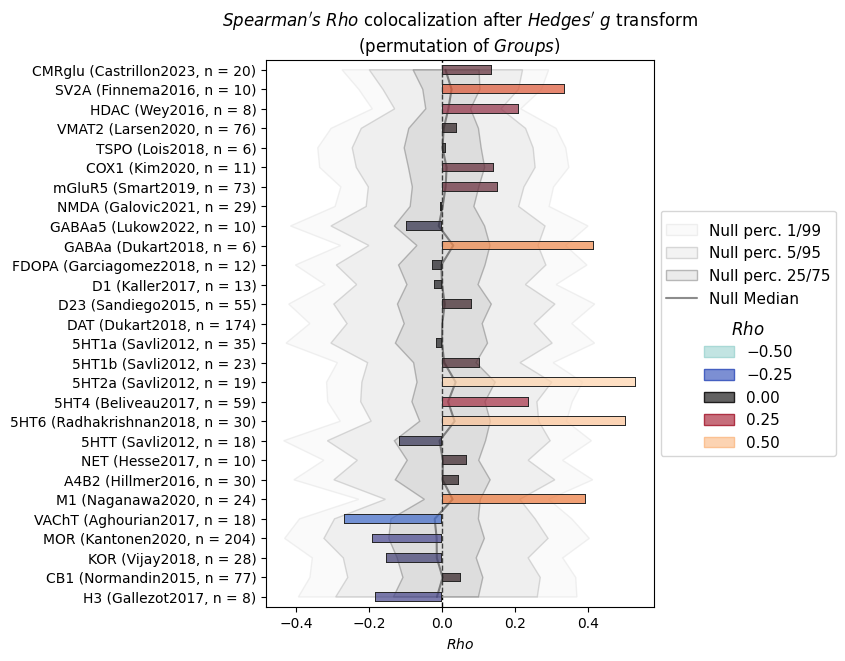

In [19]:
# rerun with Destrieux parcellation, suppress output and design matrix plotting
colocs_es, pvalues_es, qvalues_es, nsp_object_es = group_comparison(
    y=df_destrieux, # sample data
    x=df_reference_destrieux, # reference data
    parcellation="Destrieux", # parcellation
    design=groups, # group membership
    group_comparison="hedges(a,b)", # effect size difference 
    colocalization_method="spearman", # spearman correlation betw. each x and y
    n_perm=10000, # number of permutations for exact p values
    n_proc=-1, # number of cores to use (-1 = all available)
    verbose=False,
    plot_design=False,
)


There we go! The results pattern is expectedly similar, but with stronger effects. We find clear positive correlations between cortical thickness alteration patterns in fragile X syndrome and 5HT2a, 5HT6, GABAa and M1 receptors, as well as synaptic density (SV2A) and transcriptomic activity (HDAC).

The positive correlation here means that areas with increased cortical thickness in fragile X syndrome versus controls are those with the highest density of the mentioned molecules in "healthy" brains.

Let's take a short look at the FDR-corrected p values across the two parcellations:

In [20]:
pvalues_es.T["mean"].sort_values().head(6)

set                          map                                                          
Serotonin                    target-5HT6_tracer-gsk215083_n-30_dx-hc_pub-radhakrishnan2018    0.0001
                             target-5HT2a_tracer-altanserin_n-19_dx-hc_pub-savli2012          0.0006
Noradrenaline/Acetylcholine  target-M1_tracer-lsn3172176_n-24_dx-hc_pub-naganawa2020          0.0008
General                      target-SV2A_tracer-ucbj_n-10_dx-hc_pub-finnema2016               0.0020
GABA                         target-GABAa_tracer-flumazenil_n-6_dx-hc_pub-dukart2018          0.0020
General                      target-HDAC_tracer-martinostat_n-8_dx-hc_pub-wey2016             0.0238
Name: mean, dtype: float32

And this would be what the correlation itself looks like for a single reference map:

Text(0.5, 1.0, "Correlation between Hedges' g and 5HT2a density per parcel")

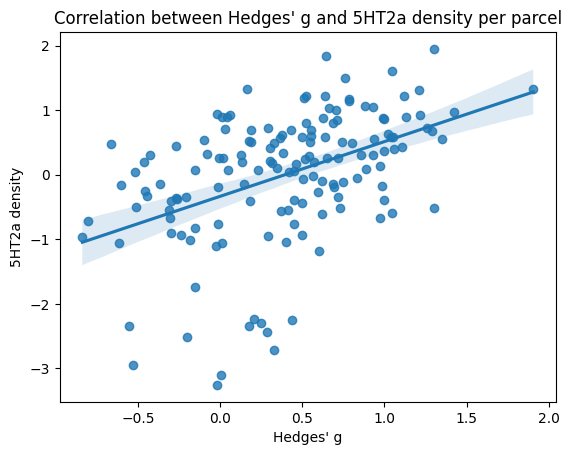

In [21]:
import matplotlib.pyplot as plt
from seaborn import regplot

regplot(
    x=nsp_object_es.get_y(Y_transform="hedges(a,b)").loc["hedges"],
    y=df_reference_destrieux.loc[("Serotonin", "target-5HT2a_tracer-altanserin_n-19_dx-hc_pub-savli2012")],
)
plt.xlabel("Hedges' g")
plt.ylabel("5HT2a density")
plt.title("Correlation between Hedges' g and 5HT2a density per parcel")


#### Advanced analyses: Group comparison using single-subject zscores

This is the standard workflow introduced with the [JuSpace toolbox](https://doi.org/10.1002/hbm.25244). 
The difference to above is that we do not calculate a single group-level effect size map, but instead we will calculate a z-score map for each subject as in `( case_subject - mean(control_subjects) ) / sd(control_subjects)`. The automatically generated plots will show individual-level values as dots instead of the bars seen above.

The results should be similar but we will have single-subject correlation coefficients, which is quite useful for follow-up analyses. I.e., we could check whether the individual alignment with a given PET map is associated with a clinical variable of interest.

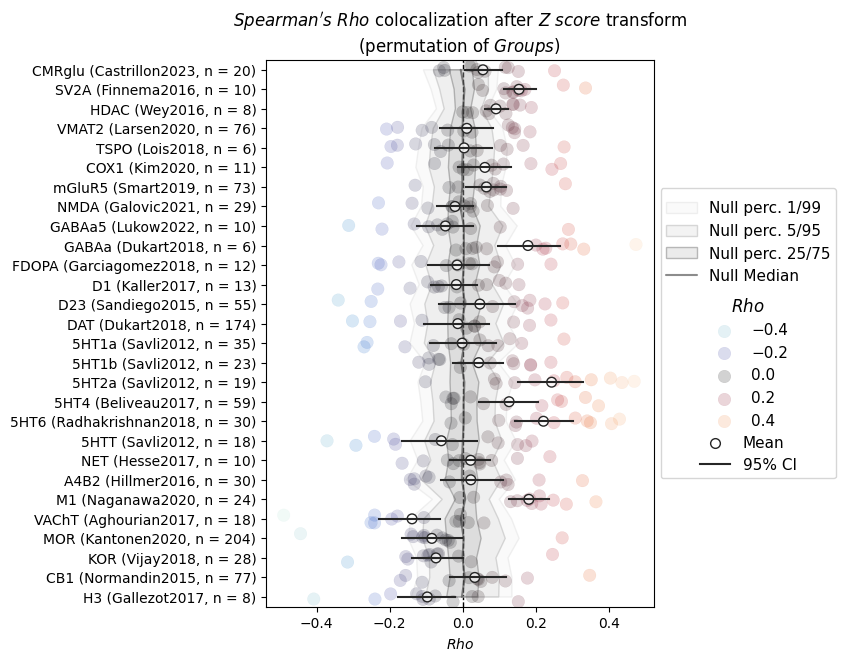

In [22]:
colocs_zscore, pvalues_zscore, qvalues_zscore, nsp_object_zscore = group_comparison(
    y=df_destrieux, # sample data
    x=df_reference_destrieux, # reference data
    parcellation="Destrieux", # parcellation
    design=groups, # group membership
    group_comparison="zscore(a,b)",
    colocalization_method="spearman", # spearman correlation betw. each x and y
    n_perm=10000, # number of permutations for exact p values
    n_proc=-1, # number of cores to use (-1 = all available)
    verbose=False,
    plot_design=False,
)


As we now have single-subject correlation coefficients for all FrX subjects, the resulting colocalization dataframe will have one row for each subject. P values, however, are by default calculated for the mean of the sample, so they will still have one row across all subjects.


In [23]:
display("Colocalization:", colocs_zscore.head(3))
display("P values:", pvalues_zscore)

'Colocalization:'

set                                                     General  \
map      target-CMRglu_tracer-fdg_n-20_dx-hc_pub-castrillon2023   
sub-HM06                                          -0.052154       
sub-HM09                                           0.124604       
sub-HM10                                           0.251400       

set                                                          \
map      target-SV2A_tracer-ucbj_n-10_dx-hc_pub-finnema2016   
sub-HM06                                           0.160403   
sub-HM09                                           0.112639   
sub-HM10                                           0.170240   

set                                                            \
map      target-HDAC_tracer-martinostat_n-8_dx-hc_pub-wey2016   
sub-HM06                                          -0.000030     
sub-HM09                                           0.027052     
sub-HM10                                           0.187775     

set                                                          \
map      target-VMAT2_tracer-dtbz_n-76_dx-hc_pub-larsen2020   
sub-HM06                                           0.135741   
sub-HM09                                           0.025278   
sub-HM10                                          -0.208785   

set                                             Immunity  \
map      target-TSPO_tracer-pbr28_n-6_dx-hc_pub-lois2018   
sub-HM06                                        0.165371   
sub-HM09                                       -0.179021   
sub-HM10                                       -0.196611   

set                                                      \
map      target-COX1_tracer-ps13_n-11_dx-hc_pub-kim2020   
sub-HM06                                       0.029338   
sub-HM09                                      -0.077251   
sub-HM10                                       0.078853   

set                                                 Glutamate  \
map      target-mGluR5_tracer-abp688_n-73_dx-hc_pub-smart2019   
sub-HM06                                           0.047107     
sub-HM09                                           0.103991     
sub-HM10                                           0.084129     

set                                                           \
map      target-NMDA_tracer-ge179_n-29_dx-hc_pub-galovic2021   
sub-HM06                                           0.028278    
sub-HM09                                          -0.010543    
sub-HM10                                          -0.029649    

set                                                        GABA  \
map      target-GABAa5_tracer-ro154513_n-10_dx-hc_pub-lukow2022   
sub-HM06                                           0.102685       
sub-HM09                                          -0.132936       
sub-HM10                                          -0.221222       

set                                                               ...  \
map      target-GABAa_tracer-flumazenil_n-6_dx-hc_pub-dukart2018  ...   
sub-HM06                                           0.036787       ...   
sub-HM09                                           0.027200       ...   
sub-HM10                                          -0.018463       ...   

set                                                          Serotonin  \
map      target-5HT6_tracer-gsk215083_n-30_dx-hc_pub-radhakrishnan2018   
sub-HM06                                           0.147066              
sub-HM09                                          -0.032158              
sub-HM10                                           0.006804              

set                                                        \
map      target-5HTT_tracer-dasb_n-18_dx-hc_pub-savli2012   
sub-HM06                                         0.172634   
sub-HM09                                        -0.184100   
sub-HM10                                        -0.371710   

set                         Noradrenaline/Acetylcholine  \
map      target-NET_trac

'P values:'

set                                                 General  \
map  target-CMRglu_tracer-fdg_n-20_dx-hc_pub-castrillon2023   
mean                                              0.194       

set                                                      \
map  target-SV2A_tracer-ucbj_n-10_dx-hc_pub-finnema2016   
mean                                             0.0001   

set                                                        \
map  target-HDAC_tracer-martinostat_n-8_dx-hc_pub-wey2016   
mean                                             0.0008     

set                                                      \
map  target-VMAT2_tracer-dtbz_n-76_dx-hc_pub-larsen2020   
mean                                             0.8232   

set                                         Immunity  \
map  target-TSPO_tracer-pbr28_n-6_dx-hc_pub-lois2018   
mean                                          0.9414   

set                                                  \
map  target-COX1_tracer-ps13_n-11_dx-hc_pub-kim2020   
mean                                         0.2484   

set                                             Glutamate  \
map  target-mGluR5_tracer-abp688_n-73_dx-hc_pub-smart2019   
mean                                             0.1754     

set                                                       \
map  target-NMDA_tracer-ge179_n-29_dx-hc_pub-galovic2021   
mean                                             0.7638    

set                                                    GABA  \
map  target-GABAa5_tracer-ro154513_n-10_dx-hc_pub-lukow2022   
mean                                             0.4378       

set                                                           ...  \
map  target-GABAa_tracer-flumazenil_n-6_dx-hc_pub-dukart2018  ...   
mean                                             0.0002       ...   

set                                                      Serotonin  \
map  target-5HT6_tracer-gsk215083_n-30_dx-hc_pub-radhakrishnan2018   
mean                                             0.0001              

set                                                    \
map  target-5HTT_tracer-dasb_n-18_dx-hc_pub-savli2012   
mean                                           0.3604   

set                     Noradrenaline/Acetylcholine  \
map  target-NET_tracer-mrb_n-10_dx-hc_pub-hesse2017   
mean                                         0.6582   

set                                                           \
map  target-A4B2_tracer-flubatine_n-30_dx-hc_pub-hillmer2016   
mean                                             0.7058        

set                                                           \
map  target-M1_tracer-lsn3172176_n-24_dx-hc_pub-naganawa2020   
mean                                             0.0001        

set                                                          \
map  target-VAChT_tracer-feobv_n-18_dx-hc_pub-aghourian2017   
mean                                              0.026       

set                                     Opiods/Endocannabinoids  \
map  target-MOR_tracer-carfentanil_n-204_dx-hc_pub-kantonen2020   
mean                                              0.204           

set                                                        \
map  target-KOR_tracer-ly2795050_n-28_dx-hc_pub-vijay2018   
mean                                             0.1844     

set                                                       \
map  target-CB1_tracer-omar_n-77_dx-hc_pub-normandin2015   
mean                                             0.6358    

set                                              Histamine  
map  target-H3_tracer-gsk189254_n-8_dx-hc_pub-gallezot2017  
mean                                              0.117     

[1 rows x 28 columns]

#### Advanced analyses: Group comparison including covariates

NiSpace allows for including covariates in the group comparison analysis. These will be regressed out of the subject-level parcel-wise data before any further analysis.
Here, we'll include age, euler number and total intracranial volume as covariates, and pass them in the form of a classical design matrix.

In this sample, this want have too much effects as it's rather small and homogeneous. It will gain importance, however, in larger samples.

,groups,age,euler_number,eTIV
participant_id,,,,
sub-HM02,1,20,33.0,1.852958e+06
sub-HM03,1,22,25.0,1.609761e+06
sub-HM05,1,23,32.0,1.525428e+06
sub-HM06,0,23,23.0,1.950892e+06
sub-HM07,1,20,46.0,1.856110e+06


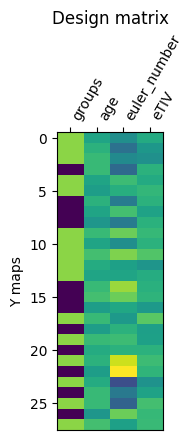

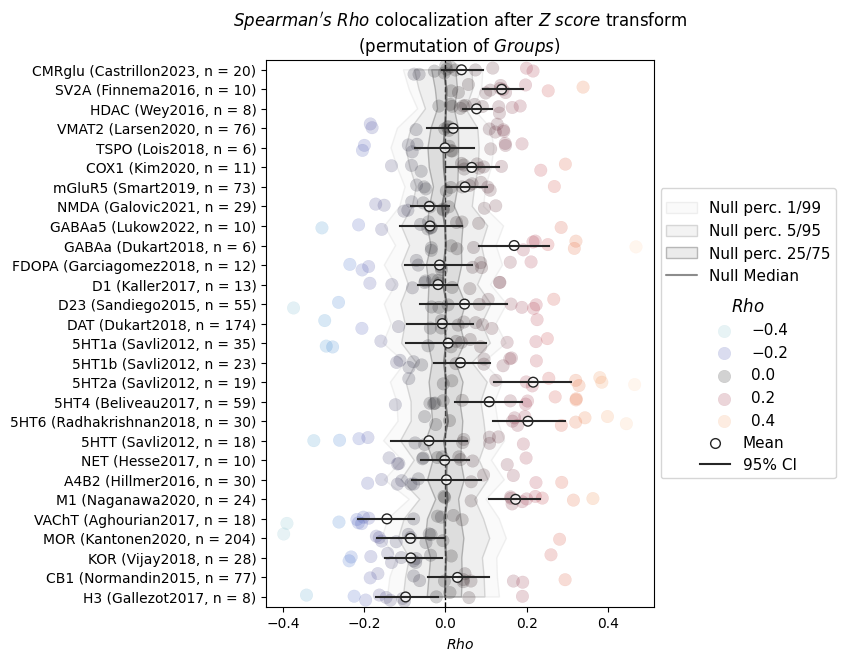

In [24]:
design = pd.DataFrame({
    "groups": df_participants.diagnosis.map({"FrX": 0, "HC": 1}),
    "age": df_participants.age,
    "euler_number": df_participants.euler_number,
    "eTIV": df_participants.eTIV
})
display(design.head(5))

# rerun with Destrieux parcellation, suppress output 
# dont save results in variables
_, _, _, _ = group_comparison(
    y=df_destrieux, # sample data
    x=df_reference_destrieux, # reference data
    parcellation="Destrieux", # parcellation
    design=design, # design matrix
    group_comparison="zscore(a,b)",
    colocalization_method="spearman", # spearman correlation betw. each x and y
    n_perm=10000, # number of permutations for exact p values
    n_proc=-1, # number of cores to use (-1 = all available)
    verbose=False,
    plot_design=True,
)

### Post-hoc analyses

As mentioned above, if using the "zscore" group comparison method, we can perform post-hoc analyses on the single-subject correlation coefficients. This just serves to demonstrate how to work with the colocalization results. 

In our small sample, we will not find much interesting.

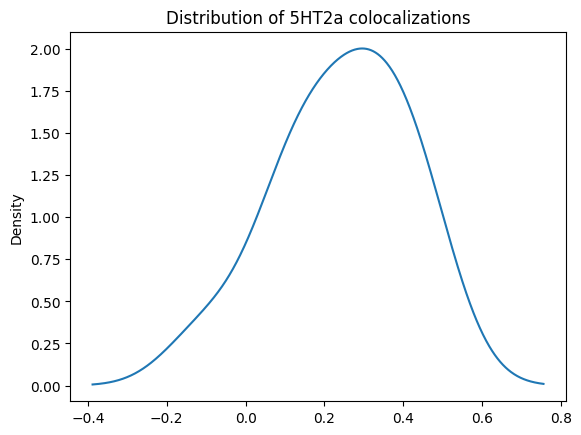

Text(0.5, 1.0, 'Correlation between 5HT2a colocalization and age in the FrX group')

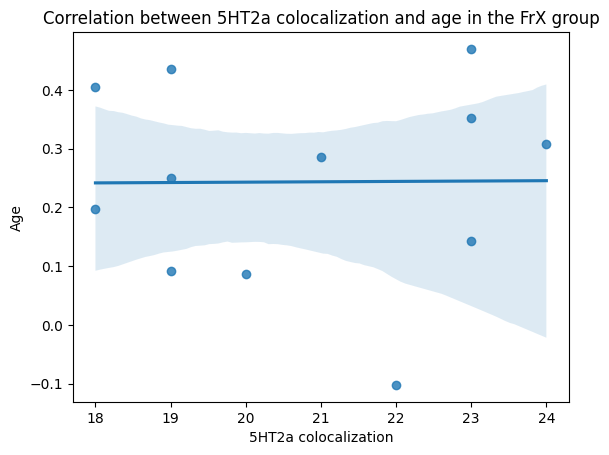

In [25]:
# colocalizations for 5HT2a 
colocs_5HT2a = colocs_zscore.loc[:, ("Serotonin", "target-5HT2a_tracer-altanserin_n-19_dx-hc_pub-savli2012")]

# show the distributions of these values
colocs_5HT2a.plot.kde(legend=False, title="Distribution of 5HT2a colocalizations")
plt.show()

# Example:
regplot(
    y=colocs_5HT2a,
    x=df_participants.age[df_participants.diagnosis == "FrX"],
)
plt.xlabel("5HT2a colocalization")
plt.ylabel("Age")
plt.title("Correlation between 5HT2a colocalization and age in the FrX group")


## Add-on: Gene-set enrichment

We found that cortical thickness alterations in fragile X syndrome are spatially associated with serotonergic and GABAergic receptor distributions, which are two of the major cortical transmitter systems. Furthermore, we observed associations to transmitter system-overarching components (synaptic density, transcriptomic activity).

We could now ask if we can further specify this, possibly system-unspecific, association. Instead of the PET data, we can also use transcriptomic data as a reference. These have the major disadvantage of being very indirect and postmortem measurements, however, we here gain the possibility of checking spatial associations to transcriptomic distributions of many individual genes or sets of genes.

We will use the [SynGO](https://doi.org/10.1016/j.neuron.2019.05.002) dataset, which consists of gene sets sorted by their implications in specific synaptic functions.

### Get effect size map from another analysis

We will perform our analysis on a parcel-wise hedge's g effect size map from the very first analysis. 
This is again based on the Desikan-Killiany parcellation. For the Allen Brain Atlas mRNA data, this makes sense it the mRNA data has a rather bad original spatial resolution that might work better with the coarser parcellation.

In [26]:
# get FrX vs HC effect size map from another analysis (no colocalization performed yet)
effect_sizes = nsp_object.get_y(Y_transform="hedges(a,b)")

# show effect size map (left hemisphere: first 74 parcels)
view_surf(effect_sizes.iloc[:, :34], parcellation="DesikanKilliany", template="fsaverage", hemi="L")

INFO | 24/01/25 17:39:54 | nispace: Returning Y dataframe: 
| Y_TRANSFORM | 
| hedges(a,b) | 


### Run the analysis

We will run the X-set enrichment analysis (XSEA) workflow function. Called like below, it will automatically fetch the "mRNA" reference data (as opposed to above, where we called the PET data independently before). The SynGO dataset is defined via the "x_collection" parameter and the special "set_size_range" parameter is used to only include gene sets with a size between 10 and inf genes (to exclude sets with only 1-5 genes).


In [27]:
from nispace.workflows import simple_xsea

# perform gene-set enrichment analysis
colocs_xsea, pvalues_xsea, qvalues_xsea, nsp_xsea = simple_xsea(
    y=effect_sizes,
    x="mrna",
    x_collection="SynGO",
    fetch_x_kwargs={"set_size_range": (10, None)},
    parcellation="DesikanKilliany",
    colocalization_method="spearman",
    n_perm=10000, 
    n_proc=-1, 
    verbose=True,
    plot=False
)

INFO | 24/01/25 17:39:54 | nispace: Trying to fetch background X dataset.
INFO | 24/01/25 17:39:54 | nispace: Loading mrna maps.
INFO | 24/01/25 17:39:54 | nispace: Loading parcellated data: DesikanKilliany
INFO | 24/01/25 17:39:54 | nispace: Standardizing parcellated data.
INFO | 24/01/25 17:39:54 | nispace: Using integrated parcellation DesikanKilliany.
INFO | 24/01/25 17:39:54 | nispace: Loading integrated mrna dataset as X data.
INFO | 24/01/25 17:39:54 | nispace: Loading mrna maps.
INFO | 24/01/25 17:39:54 | nispace: Applying collection filter from: /Users/llotter/nispace-data/reference/mrna/collection-SynGO.collect.
INFO | 24/01/25 17:39:58 | nispace: Filtering to collection sets with between 10 and inf maps.
INFO | 24/01/25 17:40:00 | nispace: Loading parcellated data: DesikanKilliany
The NiSpace "mRNA" dataset is based on Allen Human Brain Atlas (AHBA) gene expression data published in Hawrylycz et al., 
2012 (https://doi.org/10.1038/nature11405). The AHBA dataset consists of m

Colocalizing (spearman, -1 proc): 100%|██████████| 1/1 [00:00<00:00, 1979.38it/s]

INFO | 24/01/25 17:40:00 | nispace: *** NiSpace.permute() - Estimate exact non-parametric p values. ***
INFO | 24/01/25 17:40:00 | nispace: Permutation of: X sets.
INFO | 24/01/25 17:40:00 | nispace: Loading observed colocalizations (method = 'spearman').
INFO | 24/01/25 17:40:00 | nispace: Generating permuted X sets.
INFO | 24/01/25 17:40:00 | nispace: Will use 7872 provided background maps.
INFO | 24/01/25 17:40:00 | nispace: Z-standardizing X background maps.



Null colocalizations (spearman, -1 proc): 100%|██████████| 10000/10000 [01:29<00:00, 111.48it/s]


INFO | 24/01/25 17:41:35 | nispace: Calculating exact p-values (tails = {'rho': 'two'}).
INFO | 24/01/25 17:41:35 | nispace: *** NiSpace.correct_p() - Correct p values for multiple comparisons. ***
INFO | 24/01/25 17:41:35 | nispace: Returning colocalizations: 
| METHOD   | XSEA | X_REDUCTION | Y_TRANSFORM | 
| spearman | True | False       | False       | 
INFO | 24/01/25 17:41:35 | nispace: Returning p values: 
| METHOD   | PERMUTE_WHAT | XSEA | MC_METHOD | NORM  | X_REDUCTION | Y_TRANSFORM | 
| spearman | sets         | True | None      | False | False       | False       | 
INFO | 24/01/25 17:41:35 | nispace: Returning p values: 
| METHOD   | PERMUTE_WHAT | XSEA | MC_METHOD | NORM  | X_REDUCTION | Y_TRANSFORM | 
| spearman | sets         | True | fdrbh     | False | False       | False       | 


We take a look at the FDR-corrected results.

We find that the sstrongest effects are indeed again observed for quite general synaptic functions.  
We might therefore preliminarily conclude that we deal with a rather fundamental synaptic dysfunction in fragile X syndrome, rather than with a dysfunction of a specific transmitter system. 

In [28]:
qvalues_xsea.T["hedges"][qvalues_xsea.T["hedges"] < 0.05].sort_values()

synapse (GO:0045202)                                                                           0.000707
presynapse (GO:0098793)                                                                        0.000707
regulation of synapse assembly (GO:0051963)                                                    0.000707
presynaptic active zone (GO:0048786)                                                           0.000707
synapse organization (GO:0050808)                                                              0.000707
process in the postsynapse                                                                     0.000707
synaptic vesicle cycle (GO:0099504)                                                            0.000707
process in the presynapse                                                                      0.000707
postsynapse (GO:0098794)                                                                       0.000707
postsynaptic specialization (GO:0099572)                        

### Plot the results

We can now plot the results, as we did automatically in the workflow function above.  
If done manually, a plot function is called on the nispace object. With this dataset, this will produce a big plot with many categories not suitable for, e.g., papers but useful for an overview.  
We will sort the categories by colocalization strength. Consider, that this order does not have to correspond to the significance of the colocalization.

INFO | 24/01/25 17:41:35 | nispace: *** NiSpace.plot() - Plot colocalization results. ***
INFO | 24/01/25 17:41:39 | nispace: Creating categorical plot for method spearman, colocalization stat rho.


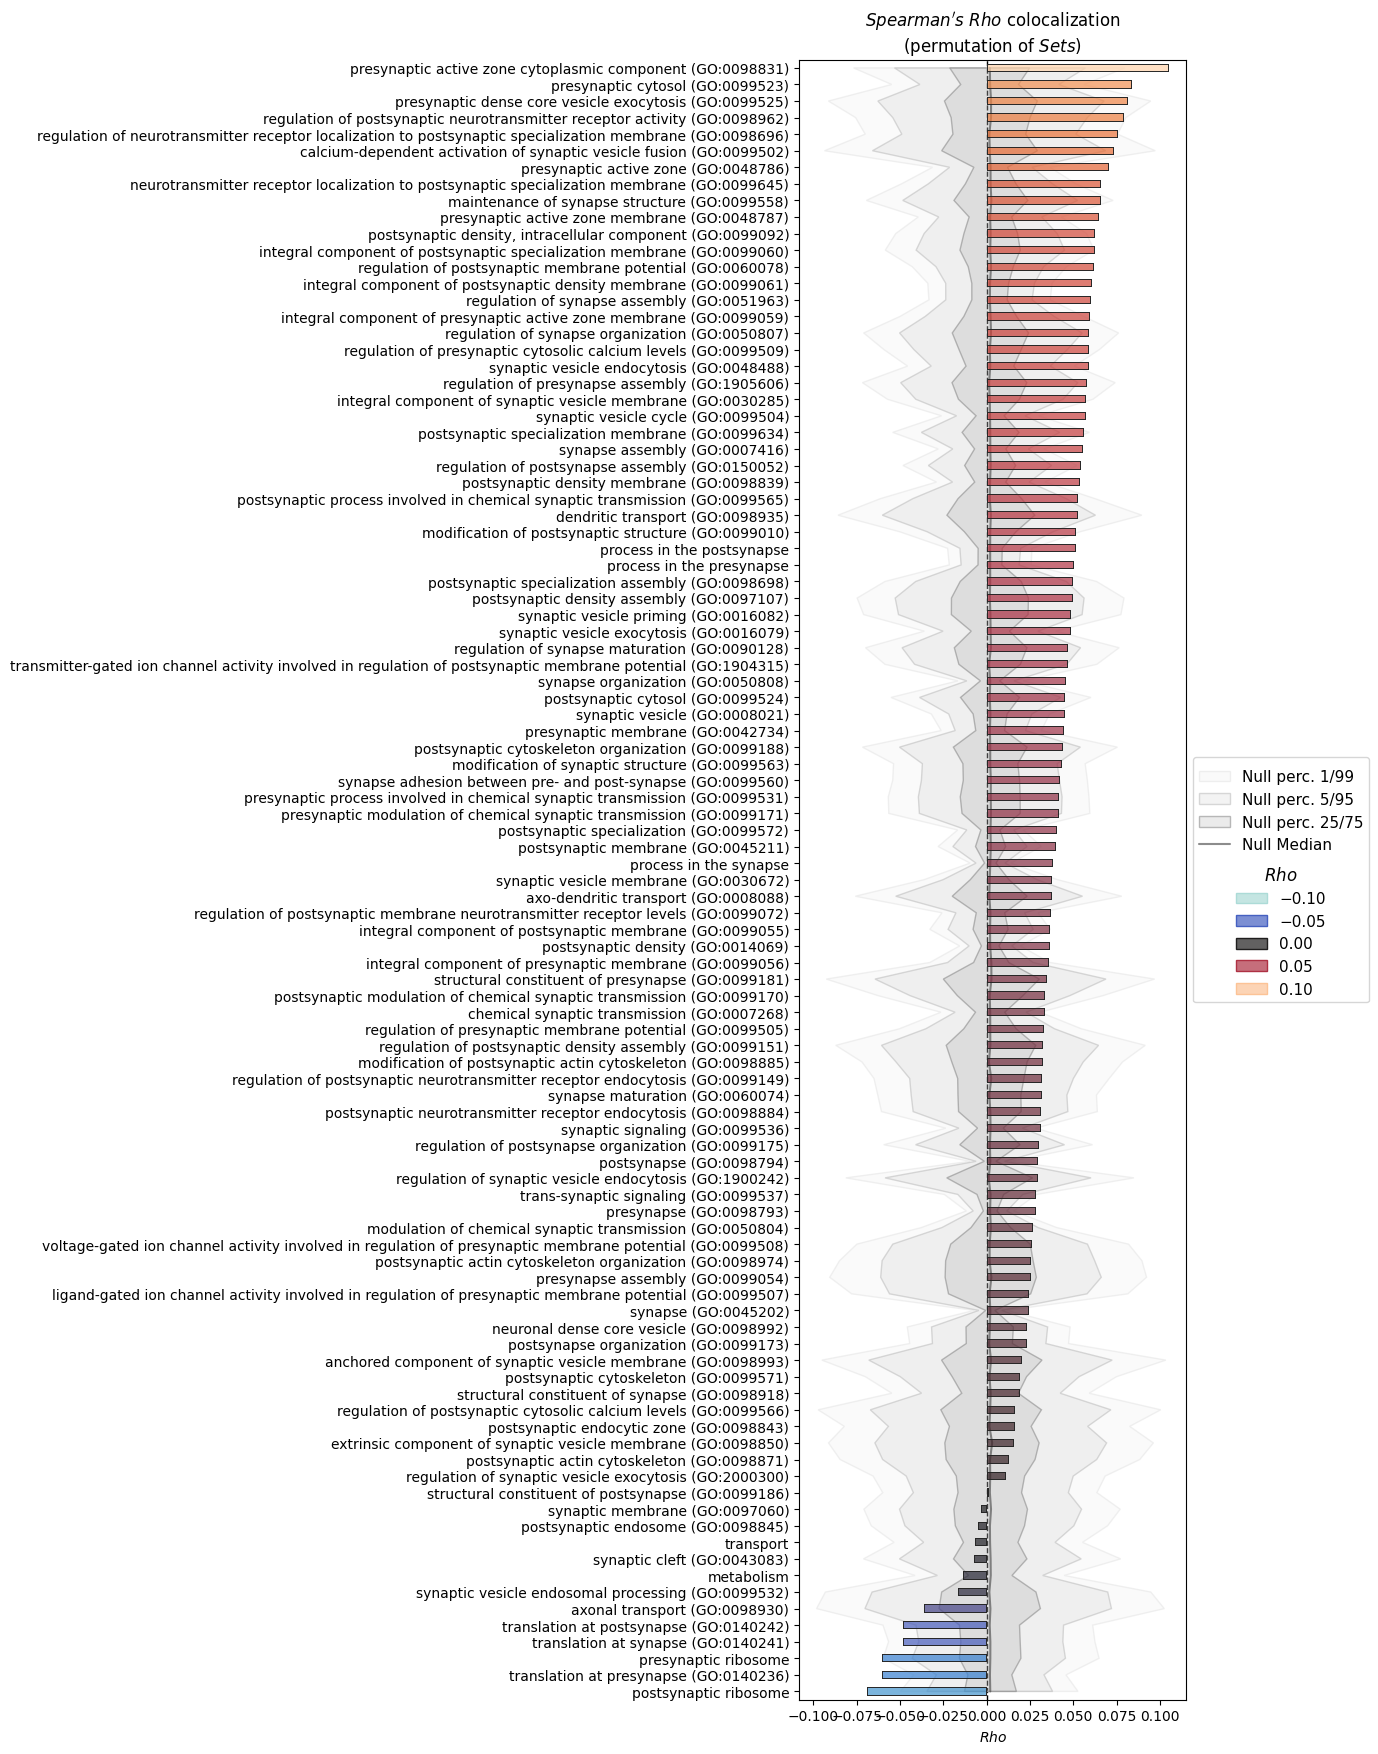

In [29]:
nsp_xsea.plot(
    plot_kwargs={"sort_categories": True}, # this will sort the categories by colocalization
)
plt.show()